USER RETENTION 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
%pip install xgboost
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


In [14]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [15]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.shape

(7043, 21)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [21]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

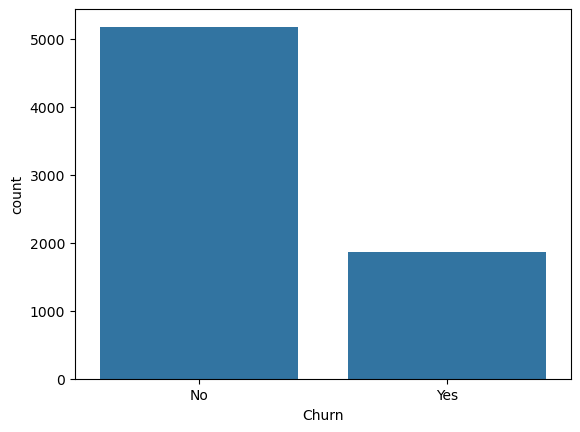

In [22]:
sns.countplot(x='Churn', data=df)

<Axes: xlabel='gender', ylabel='count'>

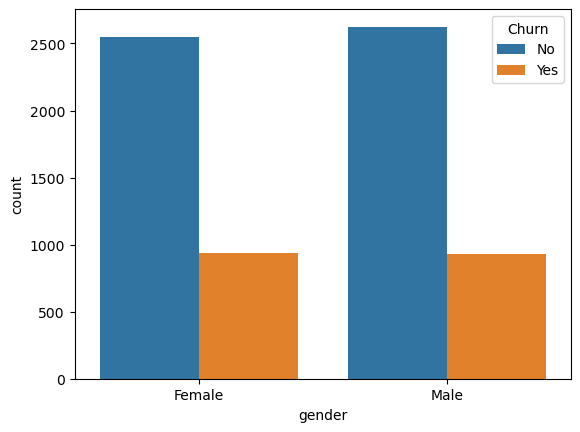

In [23]:
sns.countplot(x='gender', hue='Churn',data=df)

<Axes: xlabel='Contract', ylabel='count'>

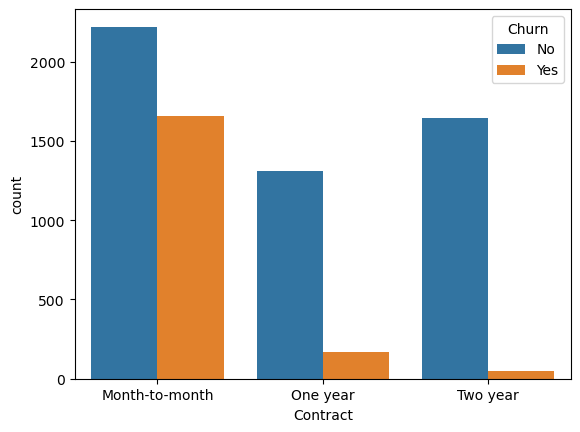

In [24]:
sns.countplot(x='Contract', hue='Churn', data=df)

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

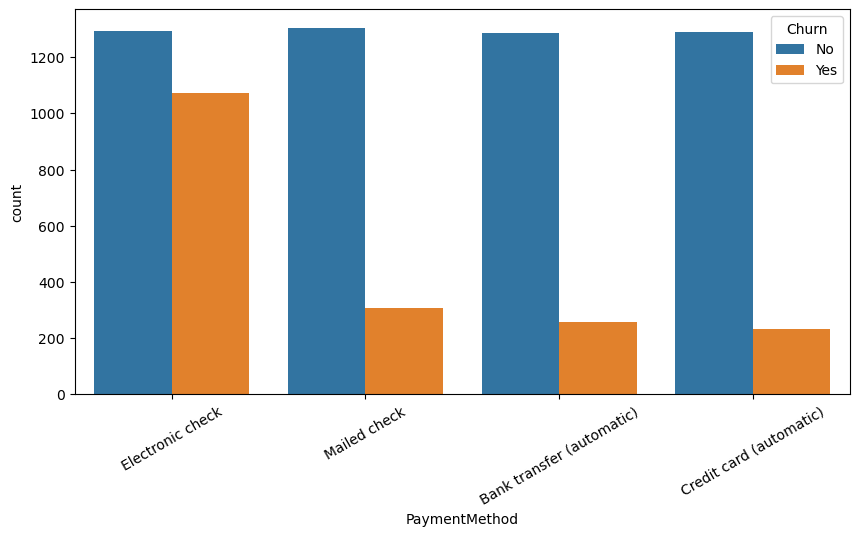

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=30)

<Axes: xlabel='InternetService', ylabel='count'>

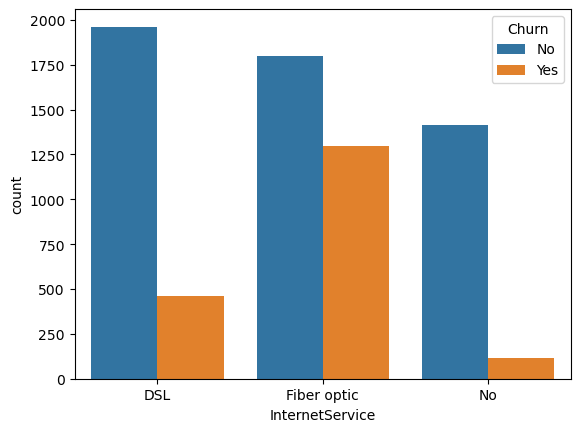

In [27]:
sns.countplot(x='InternetService', hue='Churn', data=df)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

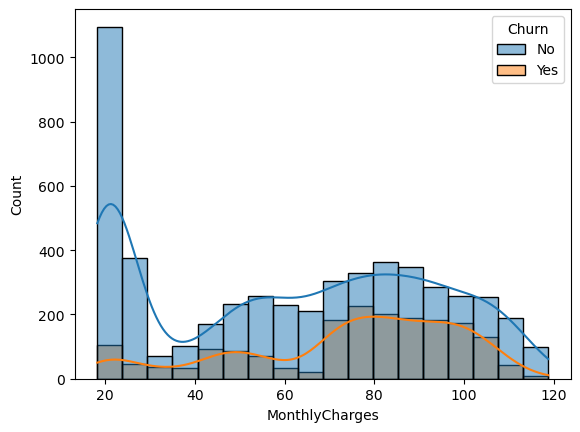

In [28]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)

<Axes: xlabel='Churn', ylabel='tenure'>

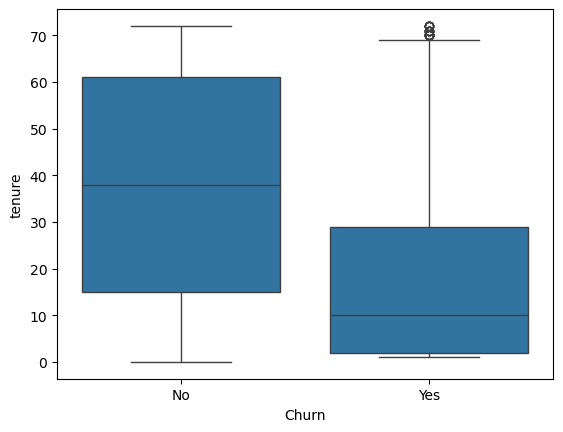

In [29]:
sns.boxplot(x='Churn', y='tenure', data=df)

In [30]:
df.drop("customerID", axis=1, inplace=True)

In [31]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [32]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [34]:
df['LifetimeValue'] = df['MonthlyCharges'] * df['tenure']

In [35]:
df['AvgSpend'] = df['TotalCharges']/(df['tenure'] + 1)

In [36]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-1 Years','1-2 Years', '2-4 Years', '4-6 Years']
)

In [37]:
services = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
df['NumServices'] = (df[services]=='Yes').sum(axis=1)

In [38]:
df = pd.get_dummies(df, drop_first=True)

In [39]:
df['Churn_Yes']

0       False
1       False
2        True
3       False
4        True
        ...  
7038    False
7039    False
7040    False
7041     True
7042    False
Name: Churn_Yes, Length: 7043, dtype: bool

In [40]:
x = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [43]:
x_train,x_test,y_train,y_test = train_test_split(
x,
y,
test_size=0.2,
random_state=42
)

In [45]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
pred_lr = lr.predict(x_test)

In [47]:
rf = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42
)
rf.fit(x_train,y_train)
pred_rf = rf.predict(x_test)

In [48]:
xgb = XGBClassifier()
xgb.fit(x_train,y_train)
pred_xgb = xgb.predict(x_test)

In [55]:
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8048261178140526
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1036
        True       0.65      0.56      0.60       373

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

[[926 110]
 [165 208]]
ROC-AUC: 0.8453321187905638


In [59]:
importance = pd.DataFrame({
'Feature':x.columns,
'Importance':rf.feature_importances_
})

importance.sort_values(
'Importance',
ascending=False
).head(15)

,Feature,Importance
3,TotalCharges,0.121174
4,LifetimeValue,0.117643
1,tenure,0.116037
2,MonthlyCharges,0.113715
5,AvgSpend,0.109066
13,InternetService_Fiber optic,0.035646
31,PaymentMethod_Electronic check,0.030515
6,NumServices,0.029046
28,Contract_Two year,0.025216
29,PaperlessBilling_Yes,0.021637


<Axes: xlabel='Importance', ylabel='Feature'>

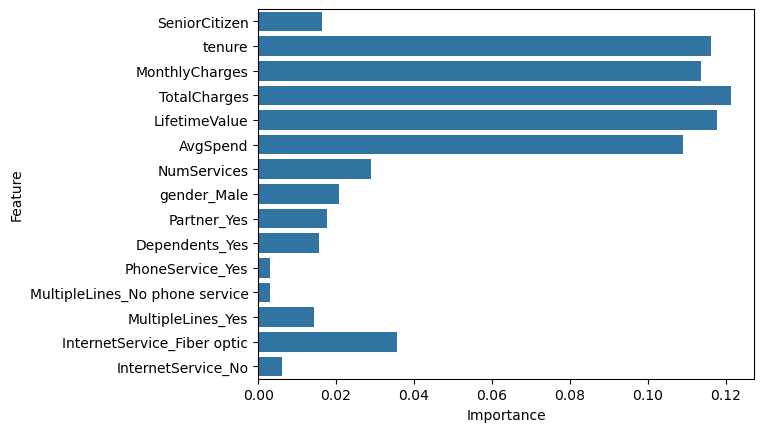

In [60]:
sns.barplot(data=importance.head(15),
           x='Importance',
           y='Feature'
           )